In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers,models

dataset_path=("/content/drive/MyDrive/ASSIGNMENT/seg_train")
train_dataset=tf.keras.utils.image_dataset_from_directory(dataset_path)


Found 14042 files belonging to 6 classes.


In [20]:
train_dataset.class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [21]:
for images, labels in train_dataset.take(1):
    print(images.shape)

(32, 256, 256, 3)


In [22]:
print(type(images))
print(type(images[0]))

<class 'tensorflow.python.framework.ops.EagerTensor'>
<class 'tensorflow.python.framework.ops.EagerTensor'>


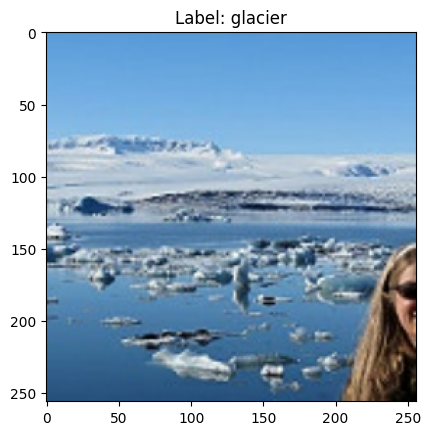

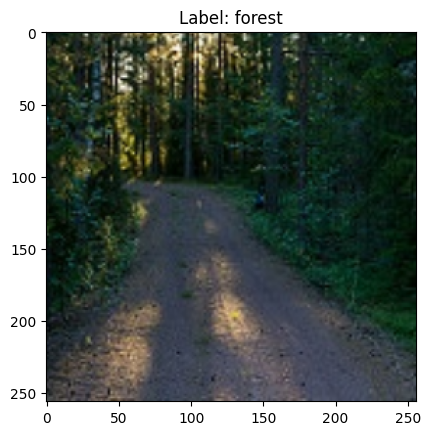

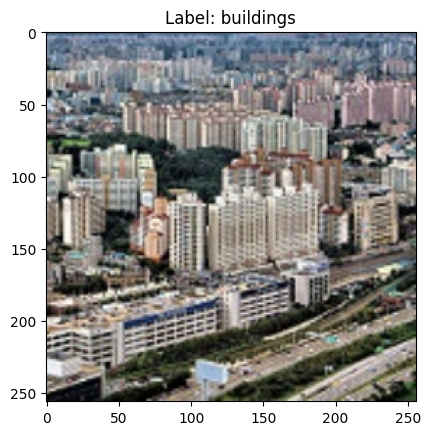

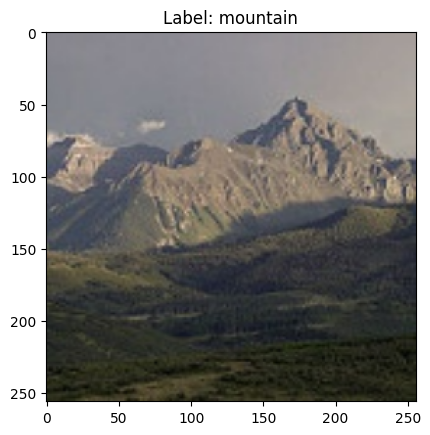

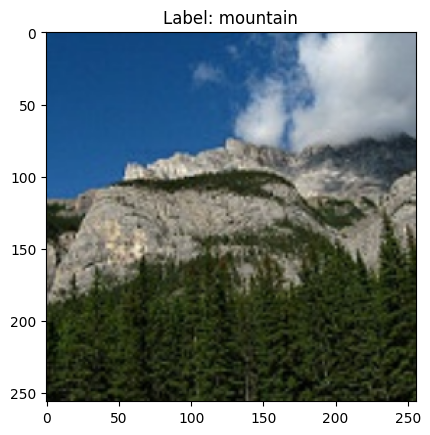

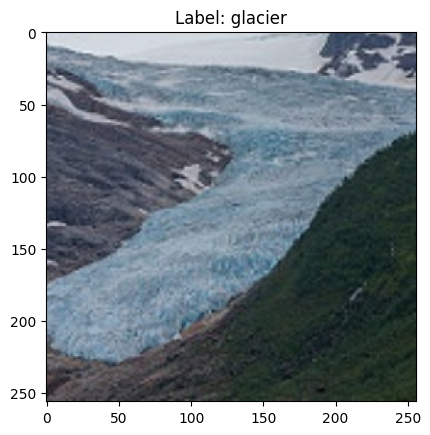

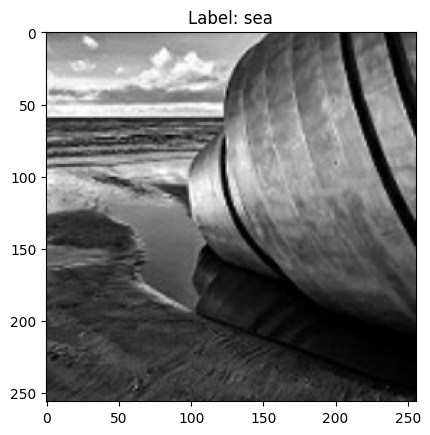

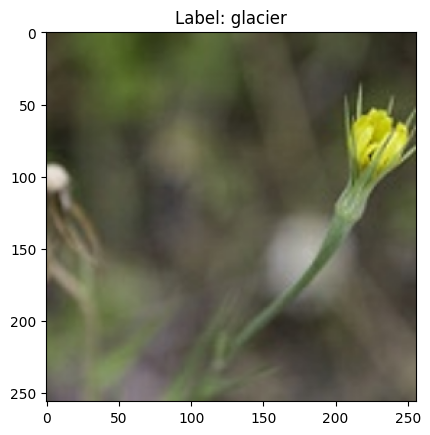

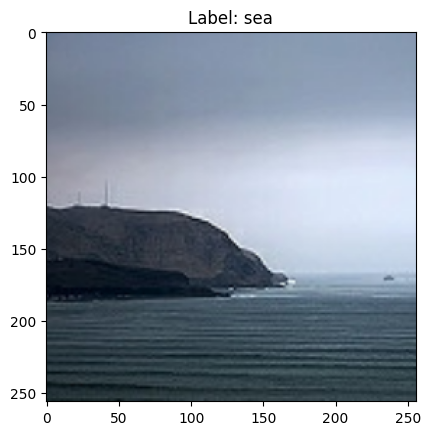

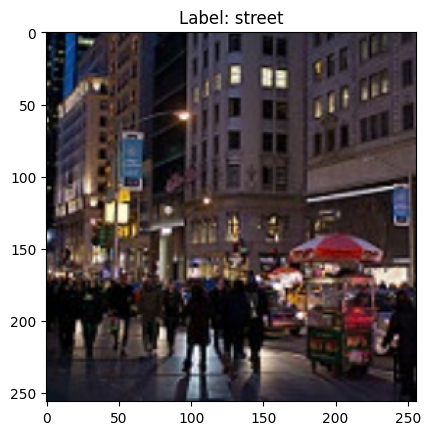

In [23]:
for i in range(10):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Label: " + train_dataset.class_names[labels[i].numpy()])
        plt.show()

In [24]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(150,150),
    validation_split=0.2,
    subset="training",
    seed=123
)

Found 14042 files belonging to 6 classes.
Using 11234 files for training.


In [25]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(150,150),
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 14042 files belonging to 6 classes.
Using 2808 files for validation.


In [26]:
test_data=("/content/drive/MyDrive/ASSIGNMENT/seg_test")
test_dataset=tf.keras.utils.image_dataset_from_directory(
    test_data,
    image_size=(150,150)
)

Found 3000 files belonging to 6 classes.


In [27]:
train_dataset=train_dataset.map(lambda images,labels:(images/255.0,labels))
validation_dataset=validation_dataset.map(lambda images,labels:(images/255.0,labels))
test_dataset=test_dataset.map(lambda images,labels:(images/255.0,labels))


In [28]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [29]:
model=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    data_augmentation,
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6,activation='softmax')
]
)

In [30]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,750 (18.28 MB)

 Trainable params: 4,791,750 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history=model.fit(
    train_dataset,
    epochs=5,
    validation_data=validation_dataset
)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1345s 4s/step - accuracy: 0.4784 - loss: 1.2946 - val_accuracy: 0.5972 - val_loss: 1.0428
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1401s 4s/step - accuracy: 0.6017 - loss: 1.0198 - val_accuracy: 0.6920 - val_loss: 0.8393
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1346s 4s/step - accuracy: 0.6627 - loss: 0.9091 - val_accuracy: 0.7475 - val_loss: 0.6923
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1340s 4s/step - accuracy: 0.6888 - loss: 0.8523 - val_accuracy: 0.7390 - val_loss: 0.7760
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 1334s 4s/step - accuracy: 0.7224 - loss: 0.7614 - val_accuracy: 0.7507 - val_loss: 0.6999


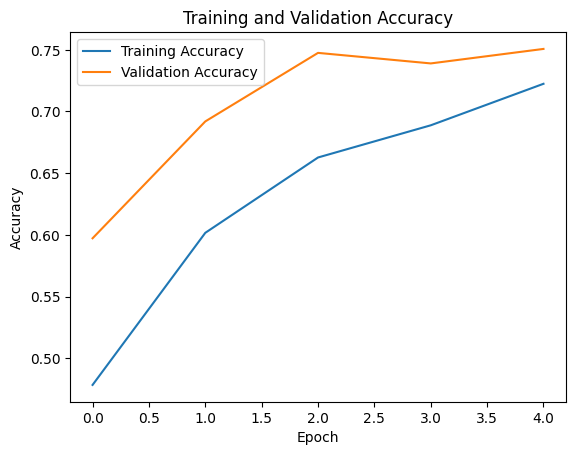

In [33]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [35]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)

print(f"Test accuracy: {test_acc:.4f}")

94/94 - 395s - 4s/step - accuracy: 0.7397 - loss: 0.7154
Test accuracy: 0.7397


In [37]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [45]:
from sklearn.metrics import classification_report

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.74      0.78      0.76       437
      forest       0.82      0.97      0.89       474
     glacier       0.64      0.76      0.70       553
    mountain       0.67      0.76      0.71       525
         sea       0.91      0.38      0.53       510
      street       0.78      0.81      0.80       501

    accuracy                           0.74      3000
   macro avg       0.76      0.74      0.73      3000
weighted avg       0.76      0.74      0.73      3000



In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)



[[339  11   2   4   2  79]
 [  2 460   0   3   0   9]
 [ 14  15 423  81   6  14]
 [ 19  15  79 400  10   2]
 [ 36  13 159 102 193   7]
 [ 48  44   0   4   1 404]]


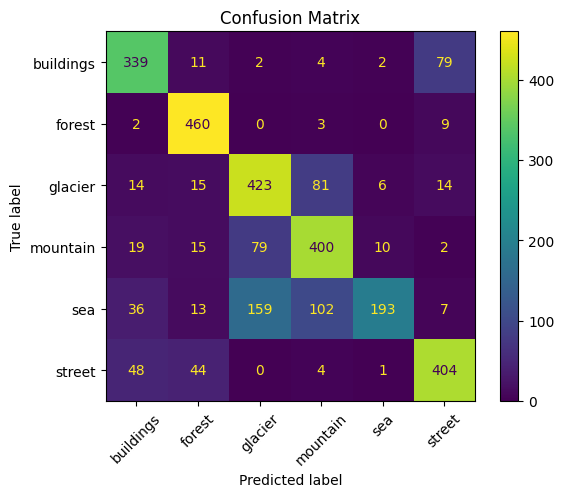

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

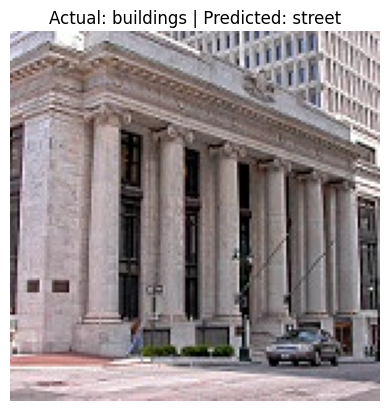

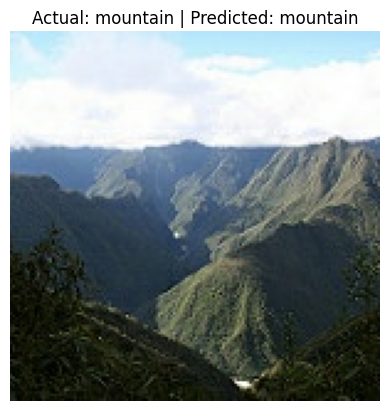

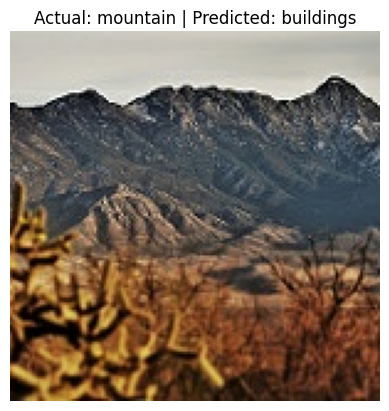

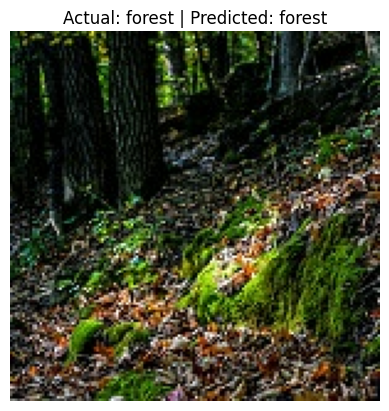

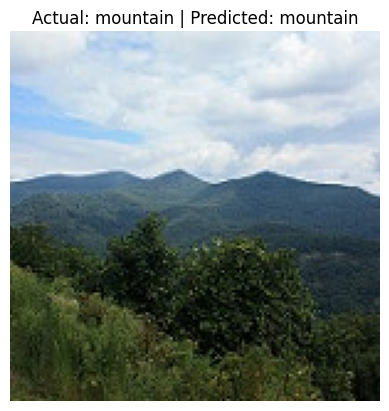

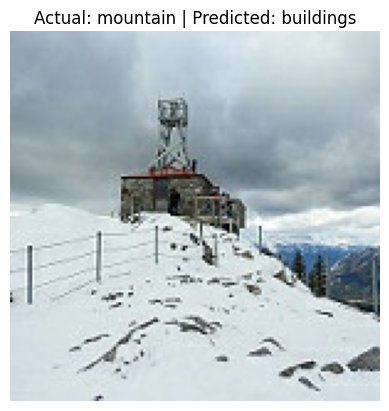

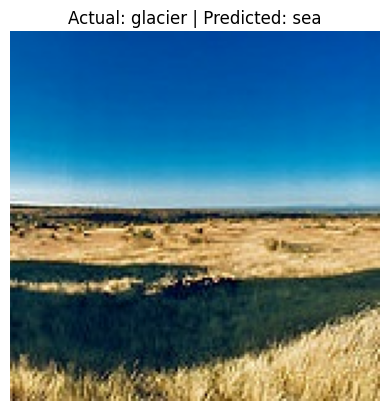

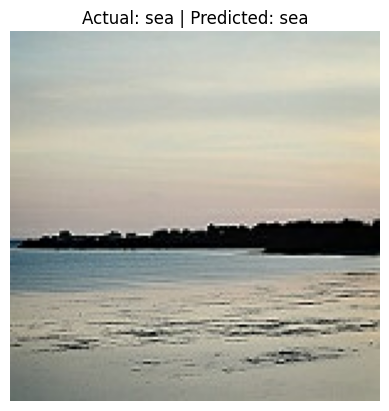

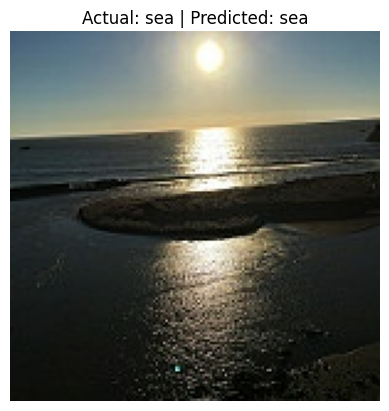

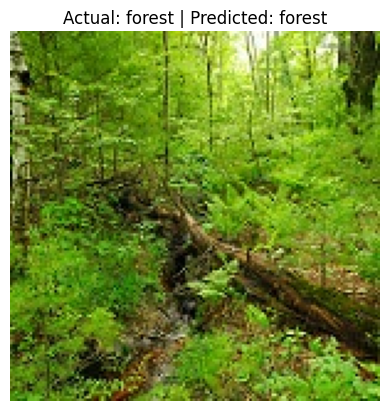

In [48]:
random_test_dataset = test_dataset.shuffle(3000).take(1)

for images, labels in random_test_dataset:

    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(10):
        plt.imshow(images[i].numpy())

        actual = class_names[labels[i].numpy()]
        predicted = class_names[predicted_labels[i]]

        plt.title(f"Actual: {actual} | Predicted: {predicted}")
        plt.axis("off")
        plt.show()